# PRACTICA 7.

## a) Retomando One hot encoding, BoW y Matriz de coocurrencia, aplica PSA y TSNe para por medio de un corpus de 700 palabras como minimo responder : ¿cómo se puede determinar cual reduce mejor la dimensión?



In [62]:
# importamos las librerias necesarias
import pandas as pd
import numpy as np

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

In [63]:
# El corpus - texto de más de 1200 palabras sobre IA
# Lo definimos como un solo string largo y luego lo dividimos
#  en 3 "documentos" para poder usar Bag of Words

doc1 = """
La inteligencia artificial es una rama de la informática que busca crear sistemas
capaces de realizar tareas que normalmente requieren inteligencia humana. Entre estas
tareas se encuentran el reconocimiento de voz, la visión por computadora, la toma de
decisiones y la traducción de idiomas. La inteligencia artificial ha evolucionado
enormemente desde sus inicios en la década de 1950, cuando Alan Turing propuso la
famosa prueba que lleva su nombre para evaluar si una máquina puede exhibir un
comportamiento inteligente indistinguible del de un ser humano. Desde entonces, los
avances en hardware, software y disponibilidad de datos han permitido que la
inteligencia artificial pase de ser una idea teórica a una tecnología presente en
nuestra vida cotidiana. Los asistentes virtuales, los sistemas de recomendación y los
vehículos autónomos son ejemplos claros de cómo la inteligencia artificial transforma
industrias enteras. El aprendizaje automático es una subdisciplina de la inteligencia
artificial que permite a las máquinas aprender de los datos sin ser programadas
explícitamente. Los algoritmos de aprendizaje automático identifican patrones en
grandes conjuntos de datos y utilizan esos patrones para hacer predicciones o tomar
decisiones. Existen tres tipos principales de aprendizaje automático: supervisado,
no supervisado y por refuerzo. En el aprendizaje supervisado, el modelo se entrena
con datos etiquetados, es decir, ejemplos donde la respuesta correcta ya es conocida.
En el aprendizaje no supervisado, el modelo busca estructuras ocultas en datos sin
etiquetar. En el aprendizaje por refuerzo, un agente aprende a tomar decisiones
interactuando con un entorno y recibiendo recompensas o penalizaciones.
"""

doc2 = """
Las redes neuronales artificiales son modelos computacionales inspirados en la
estructura del cerebro humano. Están formadas por capas de nodos o neuronas
artificiales conectadas entre sí mediante pesos que se ajustan durante el
entrenamiento. El aprendizaje profundo es una técnica de aprendizaje automático
basada en redes neuronales con muchas capas ocultas. Estas redes profundas han
demostrado resultados extraordinarios en tareas como el reconocimiento de imágenes,
el procesamiento del lenguaje natural y la generación de contenido. El procesamiento
del lenguaje natural es el campo de la inteligencia artificial que se ocupa de la
interacción entre computadoras y lenguaje humano. Mediante técnicas como la
tokenización, el análisis sintáctico y los modelos de lenguaje, las computadoras
pueden comprender, interpretar y generar texto de manera coherente. Los modelos de
lenguaje de gran escala como GPT y BERT han revolucionado el procesamiento del
lenguaje natural al ser entrenados con enormes cantidades de texto. La visión por
computadora es otra área fundamental de la inteligencia artificial que permite a las
máquinas interpretar y comprender imágenes y videos. Algoritmos como las redes
convolucionales han logrado superar el rendimiento humano en tareas de clasificación
de imágenes. La robótica es un campo estrechamente relacionado con la inteligencia
artificial donde los robots utilizan algoritmos inteligentes para percibir su entorno,
planificar acciones y ejecutar tareas físicas de manera autónoma. Los robots modernos
combinan visión por computadora, procesamiento del lenguaje y aprendizaje automático
para interactuar con el mundo de forma más natural y eficiente.
"""

doc3 = """
La ética en la inteligencia artificial es un tema de creciente importancia en la
sociedad actual. A medida que los sistemas de inteligencia artificial se vuelven más
poderosos e influyentes, surgen preguntas fundamentales sobre su impacto en el empleo,
la privacidad, la equidad y la seguridad. El sesgo algorítmico es uno de los problemas
más discutidos en la ética de la inteligencia artificial. Ocurre cuando un modelo
aprende patrones discriminatorios presentes en los datos de entrenamiento y los
reproduce en sus predicciones. Por ejemplo, sistemas de selección de personal basados
en inteligencia artificial han mostrado sesgos de género y raza heredados de datos
históricos. La privacidad de los datos es otra preocupación central, ya que los
sistemas de inteligencia artificial requieren grandes cantidades de información
personal para funcionar correctamente. La regulación de la inteligencia artificial es
un desafío global que gobiernos y organismos internacionales intentan abordar. La
Unión Europea ha propuesto marcos regulatorios para clasificar los sistemas de
inteligencia artificial según su nivel de riesgo. El futuro de la inteligencia
artificial incluye el desarrollo de sistemas más generales y flexibles conocidos como
inteligencia artificial general, que podrían realizar cualquier tarea cognitiva que
un ser humano es capaz de hacer. Los investigadores debaten si la inteligencia
artificial general es alcanzable y cuándo podría lograrse. La computación cuántica
promete acelerar significativamente el entrenamiento de modelos de inteligencia
artificial al realizar cálculos complejos de forma exponencialmente más rápida que
las computadoras clásicas. La combinación de inteligencia artificial y computación
cuántica podría desbloquear capacidades completamente nuevas en ciencia, medicina e
ingeniería.
"""

# sus stopwords
stopwords = [
    "de", "la", "el", "en", "y", "a", "los", "las", "un", "una",
    "que", "se", "es", "su", "por", "con", "del", "al", "lo", "le",
    "más", "para", "como", "si", "son", "sus", "han", "entre", "o",
    "ha", "no", "sobre", "cuando", "donde", "estos", "estas", "este",
    "esta", "fue", "ser", "puede", "desde", "hasta", "durante", "también",
    "pero", "sino", "porque", "aunque", "mientras", "mediante", "hacia",
    "bajo", "ante", "tras", "ya", "era", "sido", "muy", "e", "i"
]


Preprocesamiento

In [64]:
# -------------- Conversion del texto a minusculas --------------
def to_minusculas(texto):
    letras = ""
    for letra in texto:
        if ord(letra) >= 65 and ord(letra) <= 90:
            nueva_letra = chr(ord(letra) + 32)
            letras += nueva_letra
        else:
            letras += letra
    return letras

# -------------- Tokenizador del texto --------------

def es_valido(caracter):
  # ojito, los cambié a UTF8 pq python trabaja internamente con este y no ASCII
    c = ord(caracter)

    # Rango estándar: A-Z (65-90) y a-z (97-122)
    if (c >= 65 and c <= 90) or (c >= 97 and c <= 122):
        return True

    # Caracteres especiales del español en Unicode (UTF-8)
    # á=225, é=233, í=237, ó=243, ú=250, ñ=241
    # Á=193, É=201, Í=205, Ó=211, Ú=218, Ñ=209, ü=252, Ü=220
    vocales_tildes_n = [
        225, 233, 237, 243, 250, 241, # minúsculas
        193, 201, 205, 211, 218, 209, # mayúsculas
        252, 220                      # diéresis
    ]

    if c in vocales_tildes_n:
        return True

    return False

def tokenizador(texto, stopwords, valido):
  token = ""
  tokens = [None] * len(texto)
  j = 0

  for i in range(len(texto)):
    if valido(texto[i]):
      token += texto[i]
    else:
      if token != "":
        if token not in stopwords:
          tokens[j] = token
          j += 1
        token = ''

  return tokens[0:j]

def eliminar_stopwords(tokens):
    tokens_filtrados = []
    for token in tokens:
        if token not in stopwords:
            tokens_filtrados[len(tokens_filtrados):] = [token]
    return tokens_filtrados


def eliminar_palabras_repetidas(vector):
    vectorAUX = [vector[0]]         # arrancamos con la primera palabra
    for palabra in vector:
        if palabra not in vectorAUX:
            vectorAUX[len(vectorAUX):] = [palabra]  # inserta al final sin append
    return vectorAUX

In [65]:
# aplicamos el preprocesamiento a cada doc
doc1_tokenizado = eliminar_stopwords(tokenizador(to_minusculas(doc1), stopwords, es_valido))
doc2_tokenizado = eliminar_stopwords(tokenizador(to_minusculas(doc2), stopwords, es_valido))
doc3_tokenizado = eliminar_stopwords(tokenizador(to_minusculas(doc3), stopwords, es_valido))

# corpus completo de los 3 documentos
corpus_tokens = []
corpus_tokens[0:0] = doc1_tokenizado
corpus_tokens[len(corpus_tokens):] = doc2_tokenizado
corpus_tokens[len(corpus_tokens):] = doc3_tokenizado

# Vocabulario único de todo el corpus
vocabulario = eliminar_palabras_repetidas(corpus_tokens)

In [66]:
# imprimimos los resultados
print(f"Tokens doc1:       {len(doc1_tokenizado)}")
print(f"Tokens doc2:       {len(doc2_tokenizado)}")
print(f"Tokens doc3:       {len(doc3_tokenizado)}")
print(f"Corpus total:      {len(corpus_tokens)} tokens")
print(f"Vocabulario único: {len(vocabulario)} palabras")
print(f"\nPrimeras 15 palabras del vocabulario:\n{vocabulario[:15]}")


Tokens doc1:       142
Tokens doc2:       139
Tokens doc3:       151
Corpus total:      432 tokens
Vocabulario único: 284 palabras

Primeras 15 palabras del vocabulario:
['inteligencia', 'artificial', 'rama', 'informática', 'busca', 'crear', 'sistemas', 'capaces', 'realizar', 'tareas', 'normalmente', 'requieren', 'humana', 'encuentran', 'reconocimiento']


## One Hot Encoding

In [67]:
# ONE-HOT ENCODING
# Cada palabra del vocabulario se representa como un vector
# de longitud = tamaño del vocabulario, donde:
#   - todos los valores son 0
#   - excepto la posición que corresponde a esa palabra = 1
#
# Resultado: matriz de forma (284 palabras x 284 dimensiones)
# Es muy dispersa (sparse) porque casi todo son ceros

In [68]:
n_vocab = len(vocabulario)  # 284 palabras únicas

# Inicializamos la matriz de ceros: filas=palabras, columnas=dimensiones
matriz_ohe = np.zeros((n_vocab, n_vocab))

for i in range(n_vocab):
  palabra_one_hot = np.zeros(n_vocab) #Se genera un vector lleno de ceros del tamaño de n
  palabra_one_hot[i] = 1 #En la posición actual se pone 1
  matriz_ohe[i] = palabra_one_hot #Se guarda el vector generado en la posición i de la matriz OHE

print(matriz_ohe)

print(f"Forma de la matriz One-Hot: {matriz_ohe.shape}")
print(f"Ejemplo — '{vocabulario[0]}': {matriz_ohe[0][:10]}... (primeros 10 valores)")
print(f"Ejemplo — '{vocabulario[1]}': {matriz_ohe[1][:10]}... (primeros 10 valores)")

[[1. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 0. 1.]]
Forma de la matriz One-Hot: (284, 284)
Ejemplo — 'inteligencia': [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]... (primeros 10 valores)
Ejemplo — 'artificial': [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]... (primeros 10 valores)


## Bag of Words

In [69]:
# Cada DOCUMENTO se representa como un vector que cuenta
# cuántas veces aparece cada palabra del vocabulario en él.
#
# Resultado: matriz de forma (3 documentos x 284 palabras)
# A diferencia de OHE, aquí las filas son documentos,
# no palabras individuales

In [70]:
# Agrupamos los 3 documentos tokenizados en una lista de listas
# para poder iterar sobre ellos con índices
corpus = [None] * 3
corpus[0] = doc1_tokenizado
corpus[1] = doc2_tokenizado
corpus[2] = doc3_tokenizado

n_docs   = len(corpus)    # 3 documentos
n_palabras = len(vocabulario)  # 284 palabras únicas

# Inicializamos la matriz de ceros: filas=documentos, columnas=palabras
matriz_bow = np.zeros((n_docs, n_palabras))

# Recorremos cada documento
for i in range(n_docs):
    # Para cada palabra única del vocabulario
    for j in range(n_palabras):
        # Contamos cuántas veces aparece esa palabra en el documento i
        conteo = 0
        for palabra in corpus[i]:
            if palabra == vocabulario[j]:
                conteo = conteo + 1
        matriz_bow[i][j] = conteo

print(f"Forma de la matriz Bag of Words: {matriz_bow.shape}")
print(f"\nMatriz BoW (3 docs x 284 palabras):")

print(matriz_bow)

Forma de la matriz Bag of Words: (3, 284)

Matriz BoW (3 docs x 284 palabras):
[[ 6.  5.  1.  1.  2.  1.  2.  1.  1.  2.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  3.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  1.  1.  1.  5.  1.  1.  1.  1.  1.  1.  1.  1.
   1.  1.  1.  1.  1.  1.  2.  1.  1.  1.  1.  1.  6.  3.  1.  1.  1.  1.
   2.  1.  1.  1.  1.  2.  1.  1.  1.  1.  1.  1.  2.  1.  1.  1.  1.  4.
   2.  2.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
   0.  0.  0.  0.  0.  0.  0.  0.

In [71]:
# verificamos con las 10 palabras más frecuentes del corpus completo
frecuencias = np.sum(matriz_bow, axis=0)  # suma por columna

# Encontramos los índices de mayor a menor frecuencia
# sin usar sorted() - jiji - hacemos un ordenamiento manual por selección
indices_ordenados = [0] * n_palabras
for i in range(n_palabras):
    indices_ordenados[i] = i

# Bubble sort descendente sobre las frecuencias
for i in range(n_palabras):
    for j in range(n_palabras - i - 1):
        if frecuencias[indices_ordenados[j]] < frecuencias[indices_ordenados[j+1]]:
            # intercambio
            temp = indices_ordenados[j]
            indices_ordenados[j] = indices_ordenados[j+1]
            indices_ordenados[j+1] = temp

print(f"Top 10 palabras más frecuentes en el corpus:")
print()
for k in range(10):
    idx = indices_ordenados[k]
    print(f"  '{vocabulario[idx]}': {int(frecuencias[idx])} veces")

Top 10 palabras más frecuentes en el corpus:

  'inteligencia': 21 veces
  'artificial': 20 veces
  'aprendizaje': 9 veces
  'datos': 8 veces
  'sistemas': 7 veces
  'lenguaje': 7 veces
  'tareas': 5 veces
  'humano': 5 veces
  'automático': 5 veces
  'supervisado': 4 veces


## Matriz de Co-ocurrencia

In [72]:
# Captura qué palabras aparecen JUNTAS (una seguida de otra)
# en el texto. Si la palabra A aparece seguida de la palabra B:
#   - matriz[A][B] += 1
#   - matriz[B][A] += 1  (es simétrica)
#
# Resultado: matriz cuadrada (284 x 284)
# Cada celda [i][j] indica cuántas veces la palabra i
# apareció junto a la palabra j en el corpus

In [73]:
def indices_matriz(vector_palabras_unicas, palabra):
    # Busca la posición de una palabra dentro del vocabulario
    # Recorre todo el vocabulario comparando una a una
    for j in range(len(vector_palabras_unicas)):
        if palabra == vector_palabras_unicas[j]:
            return j   # devuelve el índice donde está la palabra
    return -1          # -1 si no la encuentra (no debería pasar)

def coocurrencia(vocabulario, texto_tokenizado):
    n = len(vocabulario)
    matriz_coo = np.zeros((n, n))  # matriz cuadrada de ceros

    # Recorremos el texto token por token
    # nos detenemos en el penúltimo porque comparamos i con i+1
    for i in range(len(texto_tokenizado) - 1):
        actual   = texto_tokenizado[i]
        siguiente = texto_tokenizado[i + 1]

        # Obtenemos los índices de ambas palabras en el vocabulario
        idx_actual   = indices_matriz(vocabulario, actual)
        idx_siguiente = indices_matriz(vocabulario, siguiente)

        # Verificamos que ambas palabras existan en el vocabulario
        if idx_actual != -1 and idx_siguiente != -1:
            if idx_actual == idx_siguiente:
                # La misma palabra aparece dos veces seguidas
                matriz_coo[idx_actual][idx_siguiente] += 1
            else:
                # Par de palabras distintas: llenamos ambos lados
                # porque la matriz es simétrica
                matriz_coo[idx_actual][idx_siguiente] += 1
                matriz_coo[idx_siguiente][idx_actual] += 1

    return matriz_coo

In [74]:
# aplicamos la matriz sobre el corpus completito
matriz_coo = coocurrencia(vocabulario, corpus_tokens)

print(f"Forma de la Matriz de Co-ocurrencia: {matriz_coo.shape}")
print(f"\nPrimeras 5x5 entradas de la matriz:")
for i in range(5):
    fila = ""
    for j in range(5):
        fila = fila + f"{int(matriz_coo[i][j]):4d} "
    print(f"  {vocabulario[i][:15]:15s} | {fila}")

Forma de la Matriz de Co-ocurrencia: (284, 284)

Primeras 5x5 entradas de la matriz:
  inteligencia    |    0   20    0    0    0 
  artificial      |   20    0    1    0    0 
  rama            |    0    1    0    1    0 
  informática     |    0    0    1    0    1 
  busca           |    0    0    0    1    0 


In [75]:
# verificamos mostrando el par de palabras con mayor co ocurrencia
max_val = 0
max_i   = 0
max_j   = 0

for i in range(len(vocabulario)):
    for j in range(i + 1, len(vocabulario)):  # triángulo superior, sin diagonal
        if matriz_coo[i][j] > max_val:
            max_val = matriz_coo[i][j]
            max_i   = i
            max_j   = j

print(f"\nPar con mayor co-ocurrencia:")
print(f"  '{vocabulario[max_i]}' + '{vocabulario[max_j]}' → {int(max_val)} veces")


Par con mayor co-ocurrencia:
  'inteligencia' + 'artificial' → 20 veces


# PCA

## PCA sobre el corpus completo

In [76]:
# Es una técnica de reducción de dimensión LINEAL.
# Busca las direcciones (componentes) donde los datos
# tienen mayor varianza y proyecta todo ahí.
#
# ¿Por qué reducir dimensión?
# - OHE tiene 284 dimensiones → imposible visualizar
# - BoW tiene 284 dimensiones → imposible visualizar
# - Co-oc tiene 284 dimensiones → imposible visualizar
# PCA nos lleva a 2D para poder graficar e interpretar
#
# IMPORTANTE sobre las matrices que tenemos:
# - OHE:   (284 palabras  x 284 dims) → reducimos a (284 x 2)
# - BoW:   (3 documentos  x 284 dims) → reducimos a (3  x 2)
# - Co-oc: (284 palabras  x 284 dims) → reducimos a (284 x 2)

In [77]:
# n_components=2 significa que queremos proyectar a 2 dimensiones
pca = PCA(n_components=2)

### PCA - One Hot Encoding

In [78]:
# -------------- PCA sobre ONE-HOT ENCODING --------------
# Entrada: matriz_ohe de forma (284, 284)
# Salida:  cada palabra representada en 2 dimensiones
pca_ohe = pca.fit_transform(matriz_ohe)

# varianza explicada: qué tanto de la información original
# conservan las 2 componentes principales
varianza_ohe = pca.explained_variance_ratio_

print(" ------ PCA — One-Hot Encoding ------ ")
print(f"Forma original:  {matriz_ohe.shape}")
print(f"Forma reducida:  {pca_ohe.shape}")
print(f"Varianza explicada por componente 1: {varianza_ohe[0]*100:.2f}%")
print(f"Varianza explicada por componente 2: {varianza_ohe[1]*100:.2f}%")
print(f"Varianza total explicada:            {sum(varianza_ohe)*100:.2f}%")

 ------ PCA — One-Hot Encoding ------ 
Forma original:  (284, 284)
Forma reducida:  (284, 2)
Varianza explicada por componente 1: 0.35%
Varianza explicada por componente 2: 0.35%
Varianza total explicada:            0.71%


### PCA sobre BoW

In [79]:
# Entrada: matriz_bow de forma (3, 284)
# Ojito: solo tenemos 3 puntos (documentos), PCA máximo
# puede darnos min(3,284)-1 = 2 componentes útiles
pca_bow = pca.fit_transform(matriz_bow)
varianza_bow = pca.explained_variance_ratio_

print(" ------ PCA — Bag of Words ------")
print(f"Forma original:  {matriz_bow.shape}")
print(f"Forma reducida:  {pca_bow.shape}")
print(f"Varianza explicada por componente 1: {varianza_bow[0]*100:.2f}%")
print(f"Varianza explicada por componente 2: {varianza_bow[1]*100:.2f}%")
print(f"Varianza total explicada:            {sum(varianza_bow)*100:.2f}%")

 ------ PCA — Bag of Words ------
Forma original:  (3, 284)
Forma reducida:  (3, 2)
Varianza explicada por componente 1: 61.91%
Varianza explicada por componente 2: 38.09%
Varianza total explicada:            100.00%


### PCA sobre Matriz de co ocurrencia

In [80]:
# Entrada: matriz_coo de forma (284, 284)
# Cada fila es una palabra representada por sus co-ocurrencias
# con todas las demás palabras del vocabulario
pca_coo = pca.fit_transform(matriz_coo)
varianza_coo = pca.explained_variance_ratio_

print(" ------ PCA — Co-ocurrencia ------")
print(f"Forma original:  {matriz_coo.shape}")
print(f"Forma reducida:  {pca_coo.shape}")
print(f"Varianza explicada por componente 1: {varianza_coo[0]*100:.2f}%")
print(f"Varianza explicada por componente 2: {varianza_coo[1]*100:.2f}%")
print(f"Varianza total explicada:            {sum(varianza_coo)*100:.2f}%")

 ------ PCA — Co-ocurrencia ------
Forma original:  (284, 284)
Forma reducida:  (284, 2)
Varianza explicada por componente 1: 25.66%
Varianza explicada por componente 2: 25.15%
Varianza total explicada:            50.81%


Resumensito de comparación

In [81]:
print(" -------------- RESUMEN PCA -------------- ")
print(f"OHE      varianza total: {sum(varianza_ohe)*100:.2f}%")
print(f"BoW      varianza total: {sum(varianza_bow)*100:.2f}%")
print(f"Co-ocur  varianza total: {sum(varianza_coo)*100:.2f}%")
print("(Mayor % = PCA conserva más información en 2D)")

 -------------- RESUMEN PCA -------------- 
OHE      varianza total: 0.71%
BoW      varianza total: 100.00%
Co-ocur  varianza total: 50.81%
(Mayor % = PCA conserva más información en 2D)


# TSNE
## TSNE One Hot Encoding


In [82]:
# Entrada: matriz_ohe de forma (284, 284)
# Cada fila es una palabra → 284 muestras
# perplexity=30 es razonable para 284 muestras
tsne_modelo_ohe = TSNE(n_components=2,
                        perplexity=30,
                        random_state=42,
                        n_iter=1000)

tsne_ohe = tsne_modelo_ohe.fit_transform(matriz_ohe)

print(" ------ t-SNE — One-Hot Encoding ------")
print(f"Forma original: {matriz_ohe.shape}")
print(f"Forma reducida: {tsne_ohe.shape}")
print(f"Primeros 3 puntos en 2D:")
for i in range(3):
    print(f"  '{vocabulario[i]}': ({tsne_ohe[i][0]:.3f}, {tsne_ohe[i][1]:.3f})")


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


 ------ t-SNE — One-Hot Encoding ------
Forma original: (284, 284)
Forma reducida: (284, 2)
Primeros 3 puntos en 2D:
  'inteligencia': (243.908, 52.424)
  'artificial': (-208.291, -4.712)
  'rama': (-291.746, 131.777)


## TSNE sobre BoW

In [83]:
# Entrada: matriz_bow de forma (3, 284)
# Solo 3 muestras (documentos), perplexity DEBE ser < 3
# Con tan pocas muestras t-SNE es poco confiable,
# pero lo aplicamos para poder comparar con PCA
tsne_modelo_bow = TSNE(n_components=2,
                        perplexity=2,
                        random_state=42,
                        n_iter=1000)

tsne_bow = tsne_modelo_bow.fit_transform(matriz_bow)

print(" ----- t-SNE — Bag of Words -----")
print(f"Forma original: {matriz_bow.shape}")
print(f"Forma reducida: {tsne_bow.shape}")
print(f"Puntos en 2D por documento:")
for i in range(3):
    print(f"  Doc{i+1}: ({tsne_bow[i][0]:.3f}, {tsne_bow[i][1]:.3f})")

 ----- t-SNE — Bag of Words -----
Forma original: (3, 284)
Forma reducida: (3, 2)
Puntos en 2D por documento:
  Doc1: (100.795, -209.366)
  Doc2: (-114.887, 22.029)
  Doc3: (193.895, 92.533)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


## TSNE sobre Matriz de Coocurrencia

In [84]:
# Entrada: matriz_coo de forma (284, 284)
# Cada fila es una palabra representada por sus vecindades
# perplexity=30 igual que OHE
tsne_modelo_coo = TSNE(n_components=2,
                        perplexity=30,
                        random_state=42,
                        n_iter=1000)

tsne_coo = tsne_modelo_coo.fit_transform(matriz_coo)

print(" ----- t-SNE — Co-ocurrencia ----- ")
print(f"Forma original: {matriz_coo.shape}")
print(f"Forma reducida: {tsne_coo.shape}")
print(f"Primeros 3 puntos en 2D:")
for i in range(3):
    print(f"  '{vocabulario[i]}': ({tsne_coo[i][0]:.3f}, {tsne_coo[i][1]:.3f})")

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


 ----- t-SNE — Co-ocurrencia ----- 
Forma original: (284, 284)
Forma reducida: (284, 2)
Primeros 3 puntos en 2D:
  'inteligencia': (-4.347, -18.004)
  'artificial': (-15.405, -10.173)
  'rama': (-2.000, -13.588)


## Diferencia PCA vs t-SNE

PCA nos dio un número concreto: % de varianza explicada por lo que podemos medir objetivamente cuánta info conserva


t-SNE NO tiene ese porcentaje, su calidad se evalúa visualmente: ¿los grupos tienen sentido semántico? esto lo veremos en las gráficas

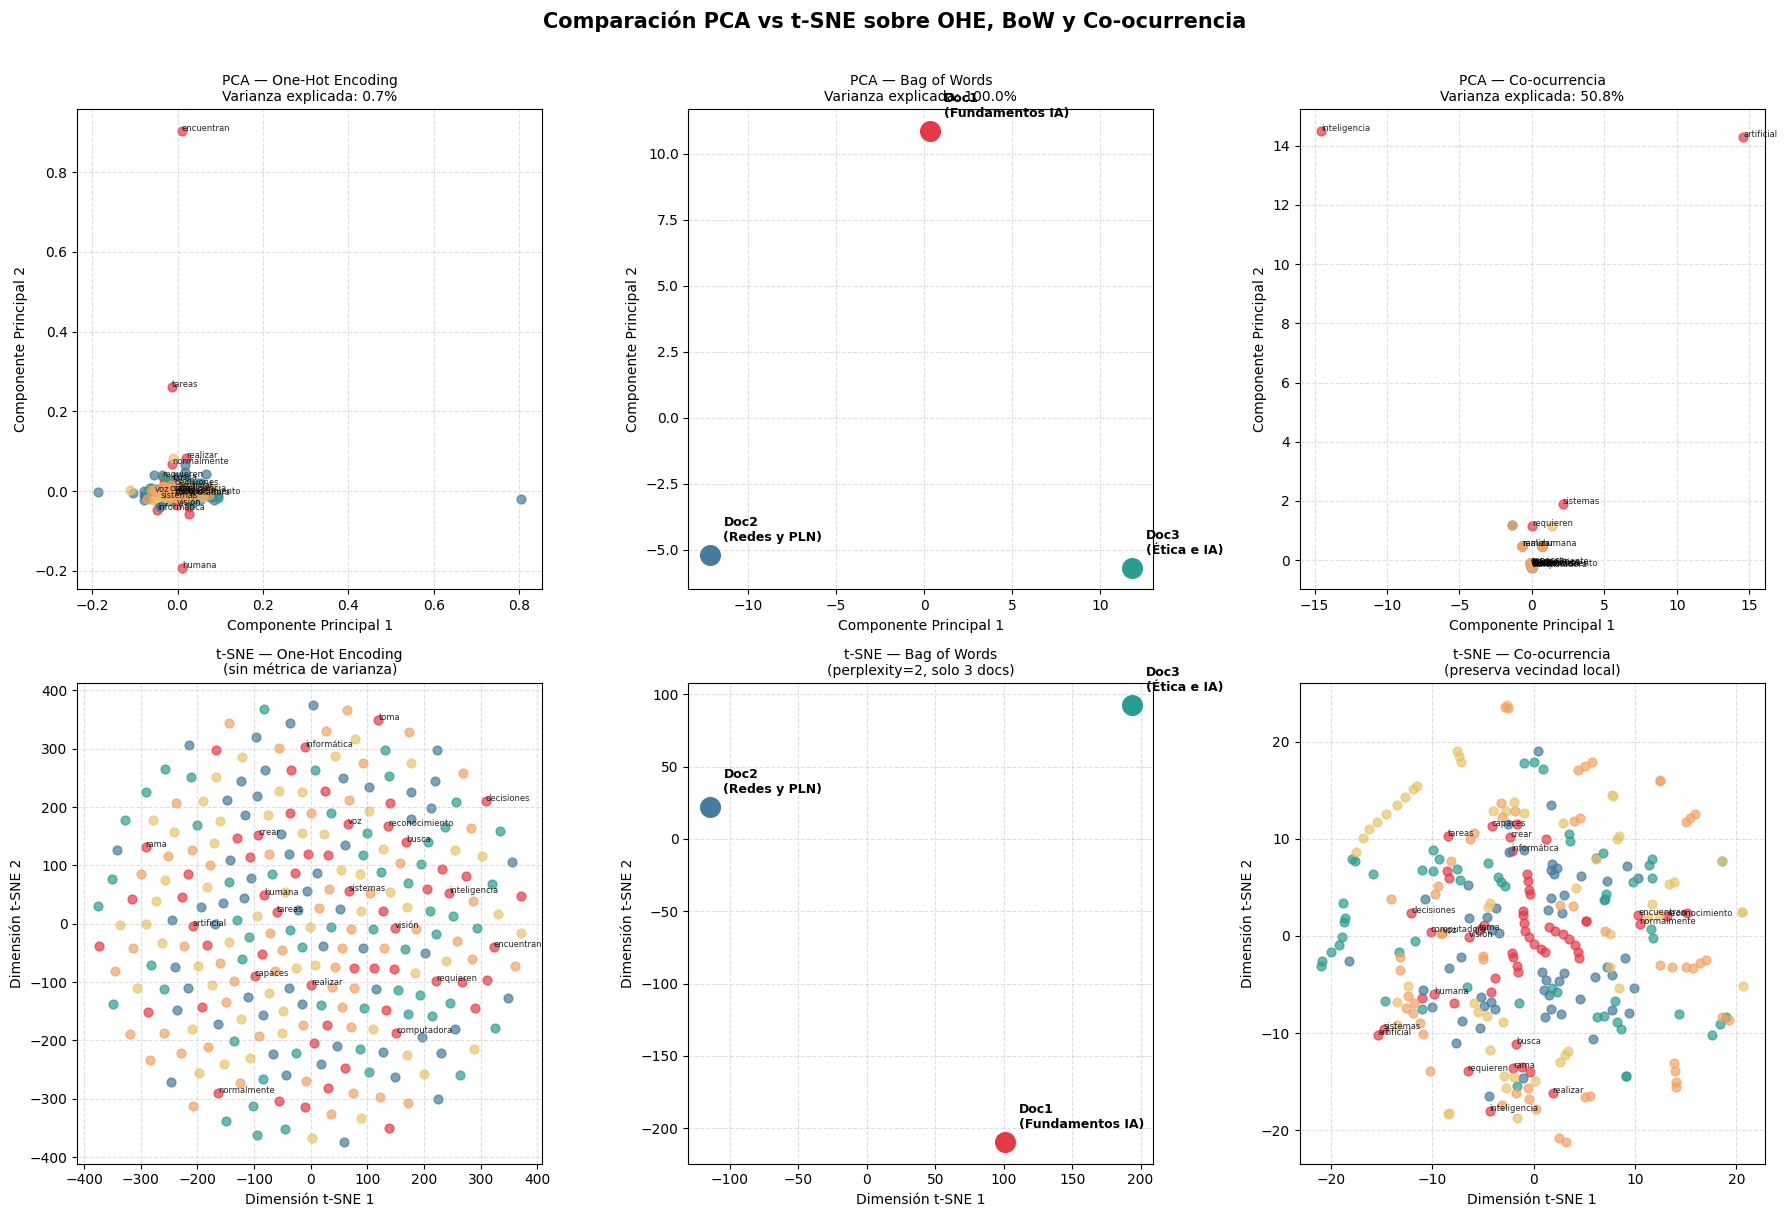

Gráfica guardada como 'comparacion_pca_tsne.png' ✓


In [ ]:
# graficamos los resultados de PCA y t-SNE
# para las 3 representaciones en una sola figura comparativa
#
# Estructura de la figura:
#   2 filas  × 3 columnas = 6 gráficas
#   Fila 1: PCA  → OHE | BoW | Co-ocurrencia
#   Fila 2: t-SNE→ OHE | BoW | Co-ocurrencia
#
# Para OHE y Co-ocurrencia graficamos palabras (284 puntos)
# Para BoW graficamos documentos (3 puntos)

fig, ejes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Comparación PCA vs t-SNE sobre OHE, BoW y Co-ocurrencia",
             fontsize=15, fontweight="bold", y=1.01)

n_vocab = len(vocabulario)
colores = ["#e63946", "#457b9d", "#2a9d8f", "#e9c46a", "#f4a261"]

lista_colores = [None] * n_vocab
for i in range(n_vocab):
    # cada bloque ocupa n_vocab//5 palabras
    bloque = (i * 5) // n_vocab
    lista_colores[i] = colores[bloque]

# FILA 0 — PCA

# ---- PCA sobre OHE ----
ax = ejes[0][0]
for i in range(n_vocab):
    ax.scatter(pca_ohe[i][0], pca_ohe[i][1],
               color=lista_colores[i], alpha=0.7, s=40)

# Etiquetamos solo las primeras 20 palabras para no saturar
for i in range(20):
    ax.annotate(vocabulario[i],
                (pca_ohe[i][0], pca_ohe[i][1]),
                fontsize=6, alpha=0.85)

ax.set_title(f"PCA — One-Hot Encoding\nVarianza explicada: {sum(varianza_ohe)*100:.1f}%",
             fontsize=10)
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.grid(True, linestyle="--", alpha=0.4)

# ---- PCA sobre BoW ----
ax = ejes[0][1]
colores_docs = ["#e63946", "#457b9d", "#2a9d8f"]
etiquetas_docs = ["Doc1\n(Fundamentos IA)", "Doc2\n(Redes y PLN)", "Doc3\n(Ética e IA)"]

for i in range(3):
    ax.scatter(pca_bow[i][0], pca_bow[i][1],
               color=colores_docs[i], s=200, zorder=5)
    ax.annotate(etiquetas_docs[i],
                (pca_bow[i][0], pca_bow[i][1]),
                fontsize=9, fontweight="bold",
                xytext=(10, 10), textcoords="offset points")

ax.set_title(f"PCA — Bag of Words\nVarianza explicada: {sum(varianza_bow)*100:.1f}%",
             fontsize=10)
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.grid(True, linestyle="--", alpha=0.4)

# ---- PCA sobre Co-ocurrencia ----
ax = ejes[0][2]
for i in range(n_vocab):
    ax.scatter(pca_coo[i][0], pca_coo[i][1],
               color=lista_colores[i], alpha=0.7, s=40)

for i in range(20):
    ax.annotate(vocabulario[i],
                (pca_coo[i][0], pca_coo[i][1]),
                fontsize=6, alpha=0.85)

ax.set_title(f"PCA — Co-ocurrencia\nVarianza explicada: {sum(varianza_coo)*100:.1f}%",
             fontsize=10)
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.grid(True, linestyle="--", alpha=0.4)


# FILA 1 — t-SNE
# ---- t-SNE sobre OHE ----
ax = ejes[1][0]
for i in range(n_vocab):
    ax.scatter(tsne_ohe[i][0], tsne_ohe[i][1],
               color=lista_colores[i], alpha=0.7, s=40)

for i in range(20):
    ax.annotate(vocabulario[i],
                (tsne_ohe[i][0], tsne_ohe[i][1]),
                fontsize=6, alpha=0.85)

ax.set_title("t-SNE — One-Hot Encoding\n(sin métrica de varianza)", fontsize=10)
ax.set_xlabel("Dimensión t-SNE 1")
ax.set_ylabel("Dimensión t-SNE 2")
ax.grid(True, linestyle="--", alpha=0.4)

# ---- t-SNE sobre BoW ----
ax = ejes[1][1]
for i in range(3):
    ax.scatter(tsne_bow[i][0], tsne_bow[i][1],
               color=colores_docs[i], s=200, zorder=5)
    ax.annotate(etiquetas_docs[i],
                (tsne_bow[i][0], tsne_bow[i][1]),
                fontsize=9, fontweight="bold",
                xytext=(10, 10), textcoords="offset points")

ax.set_title("t-SNE — Bag of Words\n(perplexity=2, solo 3 docs)", fontsize=10)
ax.set_xlabel("Dimensión t-SNE 1")
ax.set_ylabel("Dimensión t-SNE 2")
ax.grid(True, linestyle="--", alpha=0.4)

# ---- t-SNE sobre Co-ocurrencia ----
ax = ejes[1][2]
for i in range(n_vocab):
    ax.scatter(tsne_coo[i][0], tsne_coo[i][1],
               color=lista_colores[i], alpha=0.7, s=40)

for i in range(20):
    ax.annotate(vocabulario[i],
                (tsne_coo[i][0], tsne_coo[i][1]),
                fontsize=6, alpha=0.85)

ax.set_title("t-SNE — Co-ocurrencia\n(preserva vecindad local)", fontsize=10)
ax.set_xlabel("Dimensión t-SNE 1")
ax.set_ylabel("Dimensión t-SNE 2")
ax.grid(True, linestyle="--", alpha=0.4)

# Ajuste final y mostrar
plt.tight_layout()
plt.savefig("comparacion_pca_tsne.png", dpi=150, bbox_inches="tight")
plt.show()

## Para responder "¿cuál reduce mejor la dimensión?" necesitamos métricas concretas. Usaremos:

1. VARIANZA EXPLICADA (solo PCA) :qué % de información original conservan las 2 componentes, pues es la métrica más directa para PCA

2. DISPERSIÓN RELATIVA (para ambos, PCA y t-SNE): qué tan separados quedan los puntos en 2D, esta se mide como desviación estándar de las coordenadas. A mayor dispersión = mejor separación visual

3. DISTANCIA MEDIA ENTRE PUNTOS (para ambos): promedio de distancias entre todos los pares de puntos. A mayor distancia = puntos más distinguibles entre sí


In [86]:
# ============================================================
# MÉTRICA 1 — Varianza explicada (PCA únicamente)
print("\n--- MÉTRICA 1: Varianza Explicada (solo PCA) ---")
print(f"  OHE:          {sum(varianza_ohe)*100:.2f}%")
print(f"  BoW:          {sum(varianza_bow)*100:.2f}%")
print(f"  Co-ocurrencia:{sum(varianza_coo)*100:.2f}%")
print("  → Interpretación: mayor % = PCA conserva más")
print("    información de la representación original en 2D")

# ============================================================
# MÉTRICA 2 — Dispersión relativa
# Calculamos la desviación estándar de las coordenadas X e Y
# para cada resultado. La dispersión total es el promedio
# de ambas desviaciones.
print("\n--- MÉTRICA 2: Dispersión en 2D (std de coordenadas) ---")

# Función manual para calcular desviación estándar
# sin usar np.std directamente, para mantener la lógica visible
def desviacion_std(valores):
    n = len(valores)
    # paso 1: media
    media = 0.0
    for v in valores:
        media = media + v
    media = media / n
    # paso 2: varianza
    varianza = 0.0
    for v in valores:
        varianza = varianza + (v - media) ** 2
    varianza = varianza / n
    # paso 3: raíz
    return varianza ** 0.5

# Extraemos coordenadas X e Y de cada resultado
# PCA
pca_ohe_x  = [pca_ohe[i][0]  for i in range(len(pca_ohe))]
pca_ohe_y  = [pca_ohe[i][1]  for i in range(len(pca_ohe))]
pca_coo_x  = [pca_coo[i][0]  for i in range(len(pca_coo))]
pca_coo_y  = [pca_coo[i][1]  for i in range(len(pca_coo))]

# t-SNE
tsne_ohe_x = [tsne_ohe[i][0] for i in range(len(tsne_ohe))]
tsne_ohe_y = [tsne_ohe[i][1] for i in range(len(tsne_ohe))]
tsne_coo_x = [tsne_coo[i][0] for i in range(len(tsne_coo))]
tsne_coo_y = [tsne_coo[i][1] for i in range(len(tsne_coo))]

# Dispersión = promedio de std en X y en Y
disp_pca_ohe  = (desviacion_std(pca_ohe_x)  + desviacion_std(pca_ohe_y))  / 2
disp_pca_coo  = (desviacion_std(pca_coo_x)  + desviacion_std(pca_coo_y))  / 2
disp_tsne_ohe = (desviacion_std(tsne_ohe_x) + desviacion_std(tsne_ohe_y)) / 2
disp_tsne_coo = (desviacion_std(tsne_coo_x) + desviacion_std(tsne_coo_y)) / 2

print(f"  PCA  + OHE:          {disp_pca_ohe:.4f}")
print(f"  PCA  + Co-ocurrencia:{disp_pca_coo:.4f}")
print(f"  t-SNE + OHE:         {disp_tsne_ohe:.4f}")
print(f"  t-SNE + Co-ocurrencia:{disp_tsne_coo:.4f}")
print("  → Interpretación: mayor dispersión = puntos más")
print("    separados = representación más discriminativa")

# ============================================================
# MÉTRICA 3 — Distancia media entre puntos
# Calculamos el promedio de distancias euclidianas entre
# todos los pares de puntos en el espacio 2D reducido.
# Usamos solo los primeros 50 puntos para no tardar mucho
# (evitamos O(n²) sobre 284 puntos completos)
print("\n--- MÉTRICA 3: Distancia media entre puntos (primeros 50) ---")

def distancia_media(matriz_2d, limite=50):
    total_dist = 0.0
    conteo     = 0
    # recorremos todos los pares (i, j) con i < j
    for i in range(limite):
        for j in range(i + 1, limite):
            dx = matriz_2d[i][0] - matriz_2d[j][0]
            dy = matriz_2d[i][1] - matriz_2d[j][1]
            distancia = (dx**2 + dy**2) ** 0.5
            total_dist = total_dist + distancia
            conteo     = conteo + 1
    return total_dist / conteo

dist_pca_ohe   = distancia_media(pca_ohe)
dist_pca_coo   = distancia_media(pca_coo)
dist_tsne_ohe  = distancia_media(tsne_ohe)
dist_tsne_coo  = distancia_media(tsne_coo)

print(f"  PCA  + OHE:           {dist_pca_ohe:.4f}")
print(f"  PCA  + Co-ocurrencia: {dist_pca_coo:.4f}")
print(f"  t-SNE + OHE:          {dist_tsne_ohe:.4f}")
print(f"  t-SNE + Co-ocurrencia:{dist_tsne_coo:.4f}")
print("  → Interpretación: mayor distancia media = palabras")
print("    más distinguibles entre sí en el espacio reducido")

# TABLA RESUMEN FINAL
print("\n" + "=" * 60)
print("   TABLA RESUMEN FINAL")
print("=" * 60)
print(f"{'Técnica':<25} {'Var%':>6} {'Disp':>8} {'DistMedia':>10}")
print("-" * 60)
print(f"{'PCA + OHE':<25} {sum(varianza_ohe)*100:>5.1f}% {disp_pca_ohe:>8.4f} {dist_pca_ohe:>10.4f}")
print(f"{'PCA + BoW':<25} {sum(varianza_bow)*100:>5.1f}% {'N/A':>8} {'N/A':>10}")
print(f"{'PCA + Co-ocurrencia':<25} {sum(varianza_coo)*100:>5.1f}% {disp_pca_coo:>8.4f} {dist_pca_coo:>10.4f}")
print(f"{'t-SNE + OHE':<25} {'N/A':>6} {disp_tsne_ohe:>8.4f} {dist_tsne_ohe:>10.4f}")
print(f"{'t-SNE + BoW':<25} {'N/A':>6} {'N/A':>8} {'N/A':>10}")
print(f"{'t-SNE + Co-ocurrencia':<25} {'N/A':>6} {disp_tsne_coo:>8.4f} {dist_tsne_coo:>10.4f}")



--- MÉTRICA 1: Varianza Explicada (solo PCA) ---
  OHE:          0.71%
  BoW:          100.00%
  Co-ocurrencia:50.81%
  → Interpretación: mayor % = PCA conserva más
    información de la representación original en 2D

--- MÉTRICA 2: Dispersión en 2D (std de coordenadas) ---
  PCA  + OHE:          0.0593
  PCA  + Co-ocurrencia:1.2524
  t-SNE + OHE:         180.2362
  t-SNE + Co-ocurrencia:9.4349
  → Interpretación: mayor dispersión = puntos más
    separados = representación más discriminativa

--- MÉTRICA 3: Distancia media entre puntos (primeros 50) ---
  PCA  + OHE:           0.0947
  PCA  + Co-ocurrencia: 2.0412
  t-SNE + OHE:          311.0592
  t-SNE + Co-ocurrencia:12.0698
  → Interpretación: mayor distancia media = palabras
    más distinguibles entre sí en el espacio reducido

   TABLA RESUMEN FINAL
Técnica                     Var%     Disp  DistMedia
------------------------------------------------------------
PCA + OHE                   0.7%   0.0593     0.0947
PCA + BoW    

# Conclusión de A):

* PCA + Co-ocurrencia es la combinación que mejor reduce la dimensión de forma INFORMATIVA, pues conserva relaciones semánticas reales y podemos medir objetivamente cuánta información retiene.
    
* t-SNE + Co-ocurrencia es la mejor opción cuando el objetivo es VISUALIZACIÓN, revela agrupamientos semánticos que PCA (al ser lineal) no puede capturar.


La elección depende del objetivo:
* Medir información retenida  -  PCA
* Explorar estructura oculta  -  t-SNE


# B)